# 01 - NFStream Exploration

## Objetivo del notebook

Este notebook explora NFStream como herramienta de reconstrucción de flows a partir de PCAPs. El objetivo no es entrenar todavía un modelo, sino entender qué columnas genera NFStream, qué representan las columnas bidireccionales y direccionales, y qué features L3/L4 parecen útiles para diferenciar tráfico normal, floods y scans.

## Dataset usado

Los PCAPs proceden de un entorno Docker aislado con tráfico generado de forma controlada. Cada PCAP representa una categoría de tráfico.

## Qué es un flow en NFStream

Un flow representa una conversación de red agregada entre dos endpoints, normalmente identificada por IP origen, IP destino, puerto origen, puerto destino y protocolo. NFStream genera columnas agregadas para el flow completo y columnas separadas por dirección.

## Restricción importante

Aunque NFStream puede extraer metadatos de aplicación mediante nDPI, este proyecto se centra en features L3/L4 sin inspección de payload. Por tanto, las columnas de aplicación se usarán solo para exploración, no como features finales de Machine Learning.

In [1]:
## celda 1
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nfstream import NFStreamer

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

# Detectar raíz del proyecto aunque el notebook se ejecute desde /notebooks
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "interim" / "nfstream_compatible"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DOCS_DIR = PROJECT_ROOT / "docs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)
print("Processed dir:", PROCESSED_DIR)

Project root: /home/angel/projects/CNC_Project
Raw data dir: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible
Processed dir: /home/angel/projects/CNC_Project/data/processed


In [2]:
## celda 2
pcap_files = sorted(RAW_DIR.rglob("*.pcap"))

pcap_inventory = pd.DataFrame({
    "pcap_path": [str(p.relative_to(PROJECT_ROOT)) for p in pcap_files],
    "file_name": [p.name for p in pcap_files],
    "size_mb": [round(p.stat().st_size / (1024 * 1024), 2) for p in pcap_files],
})

pcap_inventory

,pcap_path,file_name,size_mb
0,data/interim/nfstream_compatible/icmp_flood/ic...,icmp_flood_week1_final.pcap,320.48
1,data/interim/nfstream_compatible/normal/normal...,normal_week1_final.pcap,523.96
2,data/interim/nfstream_compatible/port_sweep/po...,port_sweep_week1_final.pcap,0.10
3,data/interim/nfstream_compatible/port_sweep/po...,port_sweep_week1_final_arp_only.pcap,0.00
4,data/interim/nfstream_compatible/syn_scan/syn_...,syn_scan_week1_final.pcap,8.27
5,data/interim/nfstream_compatible/udp_scan/udp_...,udp_scan_week1_final.pcap,1.14


## Inventario de PCAPs

La tabla anterior muestra los PCAPs disponibles para la exploración. Para esta fase se procesan todos los PCAPs encontrados, aunque los archivos marcados como smoke test no deberían usarse posteriormente como dataset final de entrenamiento.

In [3]:
##celda 3
KNOWN_LABELS = [
    "normal",
    "icmp_flood",
    "syn_scan",
    "udp_scan",
    "port_sweep",
]

def infer_label_from_path(path: Path) -> str:
    """
    Infer the traffic label from a PCAP path.

    Args:
        path: Path to a PCAP file.

    Returns:
        A string label inferred from folder names or file name.
        Returns 'unknown' if no known label is found.
    """
    text = str(path).lower()

    for label in KNOWN_LABELS:
        if label in text:
            return label

    return "unknown"


pcap_inventory["inferred_label"] = [infer_label_from_path(p) for p in pcap_files]
pcap_inventory["is_smoke_test"] = pcap_inventory["file_name"].str.lower().str.contains("smoke")

pcap_inventory

,pcap_path,file_name,size_mb,inferred_label,is_smoke_test
0,data/interim/nfstream_compatible/icmp_flood/ic...,icmp_flood_week1_final.pcap,320.48,icmp_flood,False
1,data/interim/nfstream_compatible/normal/normal...,normal_week1_final.pcap,523.96,normal,False
2,data/interim/nfstream_compatible/port_sweep/po...,port_sweep_week1_final.pcap,0.10,port_sweep,False
3,data/interim/nfstream_compatible/port_sweep/po...,port_sweep_week1_final_arp_only.pcap,0.00,port_sweep,False
4,data/interim/nfstream_compatible/syn_scan/syn_...,syn_scan_week1_final.pcap,8.27,syn_scan,False
5,data/interim/nfstream_compatible/udp_scan/udp_...,udp_scan_week1_final.pcap,1.14,udp_scan,False


In [4]:
## celda 4
def extract_flows_with_nfstream(pcap_path: Path) -> pd.DataFrame:
    """
    Extract bidirectional flows from a normalized PCAP file using NFStream.

    Args:
        pcap_path: Path to the input .pcap file.

    Returns:
        DataFrame where each row represents one network flow.

    Raises:
        FileNotFoundError: If the PCAP does not exist.
        ValueError: If NFStream returns no flows.
    """
    pcap_path = Path(pcap_path).resolve()

    if not pcap_path.exists():
        raise FileNotFoundError(f"PCAP does not exist: {pcap_path}")

    if pcap_path.stat().st_size == 0:
        raise ValueError(f"PCAP is empty: {pcap_path}")

    print(f"Reading PCAP: {pcap_path}")
    print(f"File size: {pcap_path.stat().st_size / (1024 * 1024):.2f} MB")

    streamer = NFStreamer(
        source=str(pcap_path),
        statistical_analysis=True,
        splt_analysis=10,
        n_meters=1,
    )

    df = streamer.to_pandas(columns_to_anonymize=[])

    if df is None:
        raise ValueError(
            "NFStream returned None. This usually means the PCAP format is still "
            "not compatible or NFStream could not extract valid IP flows."
        )

    if df.empty:
        raise ValueError(f"NFStream extracted 0 flows from {pcap_path}")

    df["pcap_file"] = pcap_path.name
    df["pcap_path"] = str(pcap_path.relative_to(PROJECT_ROOT))
    df["label"] = infer_label_from_path(pcap_path)
    df["is_smoke_test"] = "smoke" in pcap_path.name.lower()

    return df

In [5]:
print("RAW_DIR:", RAW_DIR)
print("Number of PCAPs:", len(pcap_files))

for p in pcap_files:
    print(p)

if not pcap_files:
    raise FileNotFoundError(f"No PCAP files found under {RAW_DIR}")

preferred_test = next(
    (p for p in pcap_files if "syn_scan" in str(p).lower() and "smoke" not in p.name.lower()),
    pcap_files[0],
)

print("\nPreferred test:")
print(preferred_test)
print("Exists:", preferred_test.exists())
print("Size MB:", preferred_test.stat().st_size / (1024 * 1024))

RAW_DIR: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible
Number of PCAPs: 6
/home/angel/projects/CNC_Project/data/interim/nfstream_compatible/icmp_flood/icmp_flood_week1_final.pcap
/home/angel/projects/CNC_Project/data/interim/nfstream_compatible/normal/normal_week1_final.pcap
/home/angel/projects/CNC_Project/data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final.pcap
/home/angel/projects/CNC_Project/data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final_arp_only.pcap
/home/angel/projects/CNC_Project/data/interim/nfstream_compatible/syn_scan/syn_scan_week1_final.pcap
/home/angel/projects/CNC_Project/data/interim/nfstream_compatible/udp_scan/udp_scan_week1_final.pcap

Preferred test:
/home/angel/projects/CNC_Project/data/interim/nfstream_compatible/syn_scan/syn_scan_week1_final.pcap
Exists: True
Size MB: 8.272499084472656


In [6]:
## celda 5
if not pcap_files:
    raise FileNotFoundError(f"No PCAP files found under {RAW_DIR}")

preferred_test = next(
    (p for p in pcap_files if "syn_scan" in str(p).lower() and "smoke" not in p.name.lower()),
    pcap_files[0]
)

print("Processing test PCAP:", preferred_test)

df_test = extract_flows_with_nfstream(preferred_test)

print("Shape:", df_test.shape)
df_test.head()

Processing test PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/syn_scan/syn_scan_week1_final.pcap
Reading PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/syn_scan/syn_scan_week1_final.pcap
File size: 8.27 MB


Shape: (60120, 93)


,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_first_seen_ms,dst2src_last_seen_ms,dst2src_duration_ms,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,src2dst_min_ps,src2dst_mean_ps,src2dst_stddev_ps,src2dst_max_ps,dst2src_min_ps,dst2src_mean_ps,dst2src_stddev_ps,dst2src_max_ps,bidirectional_min_piat_ms,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,bidirectional_max_piat_ms,src2dst_min_piat_ms,src2dst_mean_piat_ms,src2dst_stddev_piat_ms,src2dst_max_piat_ms,dst2src_min_piat_ms,dst2src_mean_piat_ms,dst2src_stddev_piat_ms,dst2src_max_piat_ms,bidirectional_syn_packets,bidirectional_cwr_packets,bidirectional_ece_packets,bidirectional_urg_packets,bidirectional_ack_packets,bidirectional_psh_packets,bidirectional_rst_packets,bidirectional_fin_packets,src2dst_syn_packets,src2dst_cwr_packets,src2dst_ece_packets,src2dst_urg_packets,src2dst_ack_packets,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_cwr_packets,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,splt_direction,splt_ps,splt_piat_ms,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,pcap_file,pcap_path,label,is_smoke_test
0,0,0,127.0.0.1,02:00:00:00:00:01,02:00:00,41525,127.0.0.11,02:00:00:00:00:02,02:00:00,46281,17,4,0,0,1779715649056,1779715649056,0,2,132,1779715649056,1779715649056,0,2,132,0,0,0,0,0,66,66.0,0.000000,66,66,66.0,0.000000,66,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[0, 0, -1, -1, -1, -1, -1, -1, -1, -1]","[66, 66, -1, -1, -1, -1, -1, -1, -1, -1]","[0, 0, -1, -1, -1, -1, -1, -1, -1, -1]",Unknown,Unspecified,0,0,NaN,NaN,NaN,NaN,NaN,syn_scan_week1_final.pcap,data/interim/nfstream_compatible/syn_scan/syn_...,syn_scan,False
1,1,0,127.0.0.11,02:00:00:00:00:01,02:00:00,53,127.0.0.1,02:00:00:00:00:02,02:00:00,41525,17,4,0,0,1779715649056,1779715649056,0,2,154,1779715649056,1779715649056,0,2,154,0,0,0,0,0,66,77.0,15.556349,88,66,77.0,15.556349,88,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"[0, 0, -1, -1, -1, -1, -1, -1, -1, -1]","[66, 88, -1, -1, -1, -1, -1, -1, -1, -1]","[0, 0, -1, -1, -1, -1, -1, -1, -1, -1]",DNS,Network,0,6,server,NaN,NaN,NaN,NaN,syn_scan_week1_final.pcap,data/interim/nfstream_compatible/syn_scan/syn_...,syn_scan,False
2,2,0,172.20.0.30,02:00:00:00:00:01,02:00:00,38229,172.20.0.10,02:00:00:00:00:02,02:00:00,445,6,4,0,0,1779715649141,1779715649142,1,2,112,1779715649141,1779715649141,0,1,58,1779715649142,1779715649142,0,1,54,54,56.0,2.828427,58,58,58.0,0.000000,58,54,54.0,0.0,54,1,1.0,0.0,1,0,0.0,0.0,0,0,0.0,0.0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,"[0, 1, -1, -1, -1, -1, -1, -1, -1, -1]","[58, 54, -1, -1, -1, -1, -1, -1, -1, -1]","[0, 1, -1, -1, -1, -1, -1, -1, -1, -1]",SMBv23,System,1,1,NaN,NaN,NaN,NaN,NaN,syn_scan_week1_final.pcap,data/interim/nfstream_compatible/syn_scan/syn_...,syn_scan,False
3,3,0,172.20.0.30,02:00:00:00:00:01,02:00:00,38229,172.20.0.10,02:00:00:00:00:02,02:00:00,995,6,4,0,0,1779715649142,1779715649142,0,2,112,1779715649142,1779715649142,0,1,58,1779715649142,1779715649142,0,1,54,54,56.0,2.828427,58,58,58.0,0.000000,58,54,54.0,0.0,54,0,0.0,0.0,0,0,0.0,0.0,0,0,0.0,0.0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,"[0, 1, -1, -1, -1, -1, -1, -1, -1, -1]","[58, 54, -1, -1, -1, -1, -1, -1, -1, -1]","[0, 0, -1, -1, -1, -1, -1, -1, -1, -1]",POPS,Email,1,1,NaN,NaN,NaN,NaN,NaN,syn_scan_week1_final.pcap,data/interim/n

## PCAP normalization for NFStream compatibility

The original PCAPs were captured in the Docker/WSL environment using Linux cooked capture v2 (`LINUX_SLL2`). Although tools such as `tcpdump` and Wireshark can read this format, NFStream failed to extract flows from it.

To solve this issue, the PCAPs were normalized into Ethernet/IP PCAPs under `data/interim/nfstream_compatible`. The normalization process preserves the original timestamps and the L3/L4 headers, but replaces the link-layer header with a synthetic Ethernet header.

This transformation is acceptable for this project because the selected features are based on L3/L4 information: IP addresses, ports, protocol, packets, bytes, duration, packet timing and TCP flags. Ethernet MAC addresses are not used as Machine Learning features.

In [7]:
## celda 6
required_columns = ["src_ip", "dst_ip", "protocol"]

for col in required_columns:
    assert col in df_test.columns, f"Missing required NFStream column: {col}"

duration_cols = [c for c in df_test.columns if "duration" in c.lower()]
byte_cols = [c for c in df_test.columns if "bytes" in c.lower()]
packet_cols = [c for c in df_test.columns if "packets" in c.lower()]
ip_cols = [c for c in df_test.columns if "ip" in c.lower()]
port_cols = [c for c in df_test.columns if "port" in c.lower()]

print("Basic required columns OK")
print()
print("Duration columns:", duration_cols)
print()
print("Byte columns:", byte_cols)
print()
print("Packet columns:", packet_cols)
print()
print("IP columns:", ip_cols)
print()
print("Port columns:", port_cols)

Basic required columns OK

Duration columns: ['bidirectional_duration_ms', 'src2dst_duration_ms', 'dst2src_duration_ms']

Byte columns: ['bidirectional_bytes', 'src2dst_bytes', 'dst2src_bytes']

Packet columns: ['bidirectional_packets', 'src2dst_packets', 'dst2src_packets', 'bidirectional_syn_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'bidirectional_urg_packets', 'bidirectional_ack_packets', 'bidirectional_psh_packets', 'bidirectional_rst_packets', 'bidirectional_fin_packets', 'src2dst_syn_packets', 'src2dst_cwr_packets', 'src2dst_ece_packets', 'src2dst_urg_packets', 'src2dst_ack_packets', 'src2dst_psh_packets', 'src2dst_rst_packets', 'src2dst_fin_packets', 'dst2src_syn_packets', 'dst2src_cwr_packets', 'dst2src_ece_packets', 'dst2src_urg_packets', 'dst2src_ack_packets', 'dst2src_psh_packets', 'dst2src_rst_packets', 'dst2src_fin_packets']

IP columns: ['src_ip', 'dst_ip', 'ip_version']

Port columns: ['src_port', 'dst_port']


## Basic validation

The first NFStream DataFrame is not empty and contains the minimum flow identification columns: source IP, destination IP and transport protocol. NFStream also exposes duration, byte and packet counters, which are the first candidate L3/L4 features for the Machine Learning pipeline.

In [8]:
## celda 7
column_inventory = pd.DataFrame({
    "column": df_test.columns,
    "dtype": [str(df_test[c].dtype) for c in df_test.columns],
    "non_null_count": [df_test[c].notna().sum() for c in df_test.columns],
    "null_count": [df_test[c].isna().sum() for c in df_test.columns],
    "null_pct": [round(df_test[c].isna().mean() * 100, 2) for c in df_test.columns],
    "example_value": [
        df_test[c].dropna().iloc[0] if df_test[c].dropna().shape[0] > 0 else np.nan
        for c in df_test.columns
    ],
})

column_inventory.sort_values("column").head(120)

,column,dtype,non_null_count,null_count,null_pct,example_value
81,application_category_name,object,60120,0,0.0,Unspecified
83,application_confidence,int64,60120,0,0.0,0
82,application_is_guessed,int64,60120,0,0.0,0
80,application_name,object,60120,0,0.0,Unknown
57,bidirectional_ack_packets,int64,60120,0,0.0,0
18,bidirectional_bytes,int64,60120,0,0.0,132
54,bidirectional_cwr_packets,int64,60120,0,0.0,0
16,bidirectional_duration_ms,int64,60120,0,0.0,0
55,bidirectional_ece_packets,int64,60120,0,0.0,0
60,bidirectional_fin_packets,int64,60120,0,0.0,0


In [9]:
## entregable celda 7
column_inventory_path = PROCESSED_DIR / "nfstream_column_inventory.csv"
column_inventory.to_csv(column_inventory_path, index=False)

print("Saved:", column_inventory_path)

Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_column_inventory.csv


In [10]:
print(f"NFStream generated {df_test.shape[1]} columns")

column_inventory[["column", "dtype", "null_pct", "example_value"]].head(30)

NFStream generated 93 columns


,column,dtype,null_pct,example_value
0,id,int64,0.0,0
1,expiration_id,int64,0.0,0
2,src_ip,object,0.0,127.0.0.1
3,src_mac,object,0.0,02:00:00:00:00:01
4,src_oui,object,0.0,02:00:00
5,src_port,int64,0.0,41525
6,dst_ip,object,0.0,127.0.0.11
7,dst_mac,object,0.0,02:00:00:00:00:02
8,dst_oui,object,0.0,02:00:00
9,dst_port,int64,0.0,46281


## Column inventory

NFStream generated a high-dimensional flow table. Each row represents a reconstructed network flow and each column represents either an identifier, a protocol field, a timing statistic, a volume counter or an optional metadata field.

The goal of this notebook is not to use all columns, but to identify which ones are useful for L3/L4 traffic characterization.

In [11]:
##agrupación de columnas
def find_columns_containing(df: pd.DataFrame, patterns: list[str]) -> list[str]:
    """
    Find columns whose name contains at least one of the provided patterns.

    Args:
        df: Input DataFrame.
        patterns: List of lowercase substrings or regex patterns.

    Returns:
        List of matching column names.
    """
    matches = []

    for col in df.columns:
        col_lower = col.lower()
        if any(re.search(pattern, col_lower) for pattern in patterns):
            matches.append(col)

    return matches


column_groups = {
    "identity": find_columns_containing(df_test, [
        r"^id$", r"src_ip", r"dst_ip", r"src_port", r"dst_port", r"protocol", r"ip_version"
    ]),
    "time_duration": find_columns_containing(df_test, [
        r"first_seen", r"last_seen", r"duration", r"time"
    ]),
    "volume_packets_bytes": find_columns_containing(df_test, [
        r"packets", r"bytes"
    ]),
    "packet_size": find_columns_containing(df_test, [
        r"_ps", r"packet_size", r"mean_ps", r"min_ps", r"max_ps"
    ]),
    "iat_or_piat": find_columns_containing(df_test, [
        r"iat", r"piat"
    ]),
    "tcp_flags": find_columns_containing(df_test, [
        r"syn", r"ack", r"rst", r"fin", r"psh", r"urg", r"ece", r"cwr"
    ]),
    "application_or_l7": find_columns_containing(df_test, [
        r"application", r"requested_server", r"user_agent", r"content_type", r"fingerprint"
    ]),
}

for group_name, cols in column_groups.items():
    print(f"\n[{group_name}] {len(cols)} columns")
    print(cols[:50])


[identity] 7 columns
['id', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'ip_version']

[time_duration] 9 columns
['bidirectional_first_seen_ms', 'bidirectional_last_seen_ms', 'bidirectional_duration_ms', 'src2dst_first_seen_ms', 'src2dst_last_seen_ms', 'src2dst_duration_ms', 'dst2src_first_seen_ms', 'dst2src_last_seen_ms', 'dst2src_duration_ms']

[volume_packets_bytes] 30 columns
['bidirectional_packets', 'bidirectional_bytes', 'src2dst_packets', 'src2dst_bytes', 'dst2src_packets', 'dst2src_bytes', 'bidirectional_syn_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'bidirectional_urg_packets', 'bidirectional_ack_packets', 'bidirectional_psh_packets', 'bidirectional_rst_packets', 'bidirectional_fin_packets', 'src2dst_syn_packets', 'src2dst_cwr_packets', 'src2dst_ece_packets', 'src2dst_urg_packets', 'src2dst_ack_packets', 'src2dst_psh_packets', 'src2dst_rst_packets', 'src2dst_fin_packets', 'dst2src_syn_packets', 'dst2src_cwr_packets', 'dst2src_ece_packets'

In [12]:
##identificar columnas candidatas
candidate_columns = [
    # Identity
    "id",
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "protocol",

    # Time
    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",
    "bidirectional_duration_ms",

    # Volume
    "bidirectional_packets",
    "bidirectional_bytes",
    "src2dst_packets",
    "src2dst_bytes",
    "dst2src_packets",
    "dst2src_bytes",

    # Packet size
    "bidirectional_min_ps",
    "bidirectional_mean_ps",
    "bidirectional_stddev_ps",
    "bidirectional_max_ps",

    # Packet inter-arrival time if available
    "bidirectional_mean_piat_ms",
    "bidirectional_stddev_piat_ms",
    "src2dst_mean_piat_ms",
    "dst2src_mean_piat_ms",
]

available_candidate_columns = [c for c in candidate_columns if c in df_test.columns]
missing_candidate_columns = [c for c in candidate_columns if c not in df_test.columns]

print("Available candidate columns:")
for col in available_candidate_columns:
    print(" -", col)

print("\nMissing candidate columns:")
for col in missing_candidate_columns:
    print(" -", col)

df_test[available_candidate_columns].head()

Available candidate columns:
 - id
 - src_ip
 - dst_ip
 - src_port
 - dst_port
 - protocol
 - bidirectional_first_seen_ms
 - bidirectional_last_seen_ms
 - bidirectional_duration_ms
 - bidirectional_packets
 - bidirectional_bytes
 - src2dst_packets
 - src2dst_bytes
 - dst2src_packets
 - dst2src_bytes
 - bidirectional_min_ps
 - bidirectional_mean_ps
 - bidirectional_stddev_ps
 - bidirectional_max_ps
 - bidirectional_mean_piat_ms
 - bidirectional_stddev_piat_ms
 - src2dst_mean_piat_ms
 - dst2src_mean_piat_ms

Missing candidate columns:


,id,src_ip,dst_ip,src_port,dst_port,protocol,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_packets,src2dst_bytes,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,src2dst_mean_piat_ms,dst2src_mean_piat_ms
0,0,127.0.0.1,127.0.0.11,41525,46281,17,1779715649056,1779715649056,0,2,132,2,132,0,0,66,66.0,0.000000,66,0.0,0.0,0.0,0.0
1,1,127.0.0.11,127.0.0.1,53,41525,17,1779715649056,1779715649056,0,2,154,2,154,0,0,66,77.0,15.556349,88,0.0,0.0,0.0,0.0
2,2,172.20.0.30,172.20.0.10,38229,445,6,1779715649141,1779715649142,1,2,112,1,58,1,54,54,56.0,2.828427,58,1.0,0.0,0.0,0.0
3,3,172.20.0.30,172.20.0.10,38229,995,6,1779715649142,1779715649142,0,2,112,1,58,1,54,54,56.0,2.828427,58,0.0,0.0,0.0,0.0
4,4,172.20.0.30,172.20.0.10,38229,443,6,1779715649142,1779715649142,0,2,112,1,58,1,54,54,56.0,2.828427,58,0.0,0.0,0.0,0.0


## Candidate L3/L4 columns

The most relevant NFStream columns for this project are related to flow identity, duration, volume, packet count, packet size and directional asymmetry.

The `bidirectional_*` columns summarize the complete flow using packets in both directions. The `src2dst_*` columns describe the initial direction of the flow, while the `dst2src_*` columns describe the reverse direction.

This distinction is important for traffic classification because normal client-server communications usually contain both requests and responses, while scans and floods often generate highly asymmetric flows.

In [13]:
##checkpoint
print("Current PCAP source directory:", RAW_DIR)
print("Number of PCAPs detected:", len(pcap_files))
print("Test DataFrame shape:", df_test.shape)
print("Available candidate columns:", len(available_candidate_columns))

Current PCAP source directory: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible
Number of PCAPs detected: 6
Test DataFrame shape: (60120, 93)
Available candidate columns: 23


In [14]:
## crear features exploratorias
def add_exploration_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add simple derived features for exploratory analysis.

    Args:
        df: NFStream DataFrame.

    Returns:
        Copy of the DataFrame with additional exploratory features.

    Network rationale:
        These features help compare traffic categories without payload inspection.
        They summarize asymmetry, packet rate and average bytes per packet.
    """
    out = df.copy()

    if {"src2dst_bytes", "dst2src_bytes"}.issubset(out.columns):
        out["bytes_asymmetry_ratio"] = (out["src2dst_bytes"] + 1) / (out["dst2src_bytes"] + 1)

    if {"src2dst_packets", "dst2src_packets"}.issubset(out.columns):
        out["packets_asymmetry_ratio"] = (out["src2dst_packets"] + 1) / (out["dst2src_packets"] + 1)

    if {"bidirectional_packets", "bidirectional_duration_ms"}.issubset(out.columns):
        duration_safe = out["bidirectional_duration_ms"].replace(0, np.nan)
        out["packets_per_ms"] = out["bidirectional_packets"] / duration_safe

    if {"bidirectional_bytes", "bidirectional_packets"}.issubset(out.columns):
        packets_safe = out["bidirectional_packets"].replace(0, np.nan)
        out["bytes_per_packet"] = out["bidirectional_bytes"] / packets_safe

    if "protocol" in out.columns:
        out["protocol_name"] = out["protocol"].map({
            1: "ICMP",
            6: "TCP",
            17: "UDP",
        }).fillna("OTHER")

    return out


df_test_exploration = add_exploration_features(df_test)

derived_cols = [
    c for c in [
        "protocol_name",
        "bytes_asymmetry_ratio",
        "packets_asymmetry_ratio",
        "packets_per_ms",
        "bytes_per_packet",
    ]
    if c in df_test_exploration.columns
]

df_test_exploration[available_candidate_columns + derived_cols].head()

,id,src_ip,dst_ip,src_port,dst_port,protocol,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_packets,src2dst_bytes,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,src2dst_mean_piat_ms,dst2src_mean_piat_ms,protocol_name,bytes_asymmetry_ratio,packets_asymmetry_ratio,packets_per_ms,bytes_per_packet
0,0,127.0.0.1,127.0.0.11,41525,46281,17,1779715649056,1779715649056,0,2,132,2,132,0,0,66,66.0,0.000000,66,0.0,0.0,0.0,0.0,UDP,133.000000,3.0,NaN,66.0
1,1,127.0.0.11,127.0.0.1,53,41525,17,1779715649056,1779715649056,0,2,154,2,154,0,0,66,77.0,15.556349,88,0.0,0.0,0.0,0.0,UDP,155.000000,3.0,NaN,77.0
2,2,172.20.0.30,172.20.0.10,38229,445,6,1779715649141,1779715649142,1,2,112,1,58,1,54,54,56.0,2.828427,58,1.0,0.0,0.0,0.0,TCP,1.072727,1.0,2.0,56.0
3,3,172.20.0.30,172.20.0.10,38229,995,6,1779715649142,1779715649142,0,2,112,1,58,1,54,54,56.0,2.828427,58,0.0,0.0,0.0,0.0,TCP,1.072727,1.0,NaN,56.0
4,4,172.20.0.30,172.20.0.10,38229,443,6,1779715649142,1779715649142,0,2,112,1,58,1,54,54,56.0,2.828427,58,0.0,0.0,0.0,0.0,TCP,1.072727,1.0,NaN,56.0


## Derived exploratory features

Several simple derived features were added to support the initial comparison between traffic categories.

- `bytes_asymmetry_ratio`: compares bytes sent in the initial direction against bytes in the reverse direction.
- `packets_asymmetry_ratio`: compares packet counts by direction.
- `packets_per_ms`: approximates the packet rate of the flow.
- `bytes_per_packet`: approximates the average packet payload intensity.

These features are not the final cleaned feature set yet, but they help validate whether the captured traffic categories show different L3/L4 behavior.

In [15]:
##procesar todos lo pcas normalizados
import time

pcap_files_for_analysis = [
    p for p in pcap_files
    if "smoke" not in p.name.lower()
]

print("PCAPs selected for analysis:")
for p in pcap_files_for_analysis:
    print(" -", p.relative_to(PROJECT_ROOT), f"({p.stat().st_size / (1024 * 1024):.2f} MB)")

if not pcap_files_for_analysis:
    raise RuntimeError("No non-smoke PCAP files found for analysis.")

PCAPs selected for analysis:
 - data/interim/nfstream_compatible/icmp_flood/icmp_flood_week1_final.pcap (320.48 MB)
 - data/interim/nfstream_compatible/normal/normal_week1_final.pcap (523.96 MB)
 - data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final.pcap (0.10 MB)
 - data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final_arp_only.pcap (0.00 MB)
 - data/interim/nfstream_compatible/syn_scan/syn_scan_week1_final.pcap (8.27 MB)
 - data/interim/nfstream_compatible/udp_scan/udp_scan_week1_final.pcap (1.14 MB)


In [16]:
all_flow_dfs = []
processing_errors = []

start_all = time.time()

for idx, pcap_path in enumerate(pcap_files_for_analysis, start=1):
    print("=" * 100)
    print(f"[{idx}/{len(pcap_files_for_analysis)}] Processing: {pcap_path.relative_to(PROJECT_ROOT)}")

    start = time.time()

    try:
        df = extract_flows_with_nfstream(pcap_path)
        df = add_exploration_features(df)

        all_flow_dfs.append(df)

        elapsed = time.time() - start
        print(f"OK -> flows={df.shape[0]}, columns={df.shape[1]}, elapsed={elapsed:.2f}s")

    except Exception as exc:
        elapsed = time.time() - start
        processing_errors.append({
            "pcap_path": str(pcap_path.relative_to(PROJECT_ROOT)),
            "error": repr(exc),
            "elapsed_seconds": round(elapsed, 2),
        })
        print(f"ERROR -> {repr(exc)}")

elapsed_all = time.time() - start_all

if not all_flow_dfs:
    raise RuntimeError("No PCAP could be processed successfully.")

all_flows = pd.concat(all_flow_dfs, ignore_index=True, sort=False)
processing_errors_df = pd.DataFrame(processing_errors)

print("=" * 100)
print("Combined DataFrame shape:", all_flows.shape)
print("Total elapsed seconds:", round(elapsed_all, 2))

processing_errors_df

[1/6] Processing: data/interim/nfstream_compatible/icmp_flood/icmp_flood_week1_final.pcap
Reading PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/icmp_flood/icmp_flood_week1_final.pcap
File size: 320.48 MB


OK -> flows=61, columns=98, elapsed=15.37s
[2/6] Processing: data/interim/nfstream_compatible/normal/normal_week1_final.pcap
Reading PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/normal/normal_week1_final.pcap
File size: 523.96 MB


OK -> flows=546, columns=98, elapsed=0.42s
[3/6] Processing: data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final.pcap
Reading PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final.pcap
File size: 0.10 MB


OK -> flows=43, columns=98, elapsed=0.07s
[4/6] Processing: data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final_arp_only.pcap
Reading PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/port_sweep/port_sweep_week1_final_arp_only.pcap
File size: 0.00 MB


ERROR -> ValueError('NFStream returned None. This usually means the PCAP format is still not compatible or NFStream could not extract valid IP flows.')
[5/6] Processing: data/interim/nfstream_compatible/syn_scan/syn_scan_week1_final.pcap
Reading PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/syn_scan/syn_scan_week1_final.pcap
File size: 8.27 MB


OK -> flows=60120, columns=98, elapsed=5.58s
[6/6] Processing: data/interim/nfstream_compatible/udp_scan/udp_scan_week1_final.pcap
Reading PCAP: /home/angel/projects/CNC_Project/data/interim/nfstream_compatible/udp_scan/udp_scan_week1_final.pcap
File size: 1.14 MB


OK -> flows=19801, columns=98, elapsed=2.07s
Combined DataFrame shape: (80571, 98)
Total elapsed seconds: 23.55


,pcap_path,error,elapsed_seconds
0,data/interim/nfstream_compatible/port_sweep/po...,ValueError('NFStream returned None. This usual...,0.05


In [17]:
##resumen pcas procesados
processed_pcaps_summary = (
    all_flows
    .groupby(["label", "pcap_file"])
    .size()
    .reset_index(name="n_flows")
    .sort_values(["label", "pcap_file"])
)

processed_pcaps_summary

,label,pcap_file,n_flows
0,icmp_flood,icmp_flood_week1_final.pcap,61
1,normal,normal_week1_final.pcap,546
2,port_sweep,port_sweep_week1_final.pcap,43
3,syn_scan,syn_scan_week1_final.pcap,60120
4,udp_scan,udp_scan_week1_final.pcap,19801


In [18]:
processed_pcaps_summary_path = PROCESSED_DIR / "nfstream_processed_pcaps_summary.csv"
processed_pcaps_summary.to_csv(processed_pcaps_summary_path, index=False)

print("Saved:", processed_pcaps_summary_path)

Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_processed_pcaps_summary.csv


## Processed PCAPs

All available non-smoke normalized PCAPs were processed with NFStream. Each PCAP was assigned a label inferred from its path. The resulting flow counts per PCAP are shown above.

Smoke-test captures were excluded from this comparison because they were used only for technical validation and could distort the category-level statistics.

In [19]:
##comparativa por categoría
summary_aggs = {}

for col in [
    "bidirectional_duration_ms",
    "bidirectional_packets",
    "bidirectional_bytes",
    "src2dst_packets",
    "src2dst_bytes",
    "dst2src_packets",
    "dst2src_bytes",
    "bidirectional_mean_ps",
    "bytes_asymmetry_ratio",
    "packets_asymmetry_ratio",
    "packets_per_ms",
    "bytes_per_packet",
]:
    if col in all_flows.columns:
        summary_aggs[f"{col}_mean"] = (col, "mean")
        summary_aggs[f"{col}_median"] = (col, "median")
        summary_aggs[f"{col}_std"] = (col, "std")

summary_by_label = (
    all_flows
    .groupby("label")
    .agg(
        n_flows=("label", "size"),
        n_pcaps=("pcap_file", "nunique"),
        **summary_aggs,
    )
    .round(3)
    .reset_index()
)

summary_by_label

,label,n_flows,n_pcaps,bidirectional_duration_ms_mean,bidirectional_duration_ms_median,bidirectional_duration_ms_std,bidirectional_packets_mean,bidirectional_packets_median,bidirectional_packets_std,bidirectional_bytes_mean,bidirectional_bytes_median,bidirectional_bytes_std,src2dst_packets_mean,src2dst_packets_median,src2dst_packets_std,src2dst_bytes_mean,src2dst_bytes_median,src2dst_bytes_std,dst2src_packets_mean,dst2src_packets_median,dst2src_packets_std,dst2src_bytes_mean,dst2src_bytes_median,dst2src_bytes_std,bidirectional_mean_ps_mean,bidirectional_mean_ps_median,bidirectional_mean_ps_std,bytes_asymmetry_ratio_mean,bytes_asymmetry_ratio_median,bytes_asymmetry_ratio_std,packets_asymmetry_ratio_mean,packets_asymmetry_ratio_median,packets_asymmetry_ratio_std,packets_per_ms_mean,packets_per_ms_median,packets_per_ms_std,bytes_per_packet_mean,bytes_per_packet_median,bytes_per_packet_std
0,icmp_flood,61,1,9428.885,0.0,73641.948,94982.197,1.0,741826.861,3989286.689,88.0,3.115672e+07,47491.590,1.0,370913.366,1994681.213,88.0,1.557836e+07,47490.607,0.0,370913.494,1994605.475,0.0,1.557837e+07,76.426,66.0,11.878,76.738,67.000,14.771,1.984,2.000,0.128,10.073,10.073,NaN,76.426,66.0,11.878
1,normal,546,1,11.824,1.0,35.937,53.762,10.0,194.644,1005387.004,1241.0,5.307160e+06,31.663,6.0,131.534,834097.681,594.0,5.301201e+06,22.099,4.0,64.000,171289.322,767.0,5.516955e+05,3952.445,112.5,7599.527,75.714,0.944,246.467,1.173,1.107,0.338,13.082,10.000,13.275,3952.445,112.5,7599.527
2,port_sweep,43,1,129.442,0.0,844.125,24.628,2.0,58.621,2040.000,112.0,5.022284e+03,23.791,1.0,58.951,1994.512,58.0,5.040123e+03,0.837,1.0,0.374,45.488,54.0,2.032200e+01,60.702,56.0,10.668,1943.306,1.073,5060.605,23.919,1.000,59.294,18.028,18.833,14.367,60.702,56.0,10.668
3,syn_scan,60120,1,0.015,0.0,0.121,2.003,2.0,0.055,112.236,112.0,3.489000e+00,1.005,1.0,0.070,58.331,58.0,4.825000e+00,0.998,1.0,0.045,53.904,54.0,2.421000e+00,56.033,56.0,0.735,1.361,1.073,6.398,1.005,1.000,0.093,2.011,2.000,0.105,56.033,56.0,0.735
4,udp_scan,19801,1,28.958,0.0,4074.561,1.016,1.0,1.841,44.361,42.0,1.316380e+02,1.014,1.0,1.699,44.224,42.0,1.200170e+02,0.002,0.0,0.146,0.137,0.0,1.178000e+01,43.232,42.0,10.659,44.319,43.000,11.579,2.001,2.000,0.087,1.590,2.000,0.791,43.232,42.0,10.659


In [20]:
summary_by_label_path = PROCESSED_DIR / "nfstream_summary_by_label.csv"
summary_by_label.to_csv(summary_by_label_path, index=False)

print("Saved:", summary_by_label_path)

Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_summary_by_label.csv


In [21]:
##distribución de protocolos por categoría
if "protocol_name" in all_flows.columns:
    protocol_distribution = (
        all_flows
        .groupby(["label", "protocol_name"])
        .size()
        .reset_index(name="n_flows")
        .sort_values(["label", "n_flows"], ascending=[True, False])
    )

    display(protocol_distribution)

    protocol_distribution_path = PROCESSED_DIR / "nfstream_protocol_distribution.csv"
    protocol_distribution.to_csv(protocol_distribution_path, index=False)

    print("Saved:", protocol_distribution_path)
else:
    print("protocol_name column not available")

,label,protocol_name,n_flows
1,icmp_flood,UDP,60
0,icmp_flood,ICMP,1
3,normal,TCP,422
4,normal,UDP,122
2,normal,OTHER,2
6,port_sweep,TCP,36
7,port_sweep,UDP,6
5,port_sweep,ICMP,1
8,syn_scan,TCP,60000
9,syn_scan,UDP,120


Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_protocol_distribution.csv


In [22]:
##top columnas con más nulos
null_report = pd.DataFrame({
    "column": all_flows.columns,
    "null_count": [all_flows[c].isna().sum() for c in all_flows.columns],
    "null_pct": [round(all_flows[c].isna().mean() * 100, 2) for c in all_flows.columns],
    "dtype": [str(all_flows[c].dtype) for c in all_flows.columns],
}).sort_values("null_pct", ascending=False)

null_report.head(30)

,column,null_count,null_pct,dtype
86,server_fingerprint,80571,100.00,float64
85,client_fingerprint,80531,99.95,object
88,content_type,80269,99.63,object
87,user_agent,80269,99.63,object
84,requested_server_name,79995,99.29,object
95,packets_per_ms,79218,98.32,float64
2,src_ip,0,0.00,object
3,src_mac,0,0.00,object
8,dst_oui,0,0.00,object
9,dst_port,0,0.00,int64


In [23]:
null_report_path = PROCESSED_DIR / "nfstream_null_report.csv"
null_report.to_csv(null_report_path, index=False)

print("Saved:", null_report_path)

Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_null_report.csv


In [24]:
tcp_flag_suffixes = (
    "_syn_packets",
    "_cwr_packets",
    "_ece_packets",
    "_urg_packets",
    "_ack_packets",
    "_psh_packets",
    "_rst_packets",
    "_fin_packets",
)

flag_columns = [
    col for col in all_flows.columns
    if col.endswith(tcp_flag_suffixes)
]

print(f"Detected {len(flag_columns)} TCP flag columns:")
flag_columns

Detected 24 TCP flag columns:


['bidirectional_syn_packets',
 'bidirectional_cwr_packets',
 'bidirectional_ece_packets',
 'bidirectional_urg_packets',
 'bidirectional_ack_packets',
 'bidirectional_psh_packets',
 'bidirectional_rst_packets',
 'bidirectional_fin_packets',
 'src2dst_syn_packets',
 'src2dst_cwr_packets',
 'src2dst_ece_packets',
 'src2dst_urg_packets',
 'src2dst_ack_packets',
 'src2dst_psh_packets',
 'src2dst_rst_packets',
 'src2dst_fin_packets',
 'dst2src_syn_packets',
 'dst2src_cwr_packets',
 'dst2src_ece_packets',
 'dst2src_urg_packets',
 'dst2src_ack_packets',
 'dst2src_psh_packets',
 'dst2src_rst_packets',
 'dst2src_fin_packets']

In [25]:
if flag_columns:
    flag_summary = (
        all_flows
        .groupby("label")[flag_columns]
        .mean(numeric_only=True)
        .round(3)
    )

    display(flag_summary)

    flag_summary_path = PROCESSED_DIR / "nfstream_tcp_flag_summary.csv"
    flag_summary.to_csv(flag_summary_path)

    print("Saved:", flag_summary_path)
else:
    print("No TCP flag columns detected in NFStream output.")

,bidirectional_syn_packets,bidirectional_cwr_packets,bidirectional_ece_packets,bidirectional_urg_packets,bidirectional_ack_packets,bidirectional_psh_packets,bidirectional_rst_packets,bidirectional_fin_packets,src2dst_syn_packets,src2dst_cwr_packets,src2dst_ece_packets,src2dst_urg_packets,src2dst_ack_packets,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_cwr_packets,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets
label,,,,,,,,,,,,,,,,,,,,,,,,
icmp_flood,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.000
normal,1.546,0.0,0.0,0.0,52.533,30.608,0.000,1.537,0.773,0.0,0.0,0.0,30.658,23.321,0.000,0.767,0.773,0.0,0.0,0.0,21.875,7.288,0.000,0.769
port_sweep,0.907,0.0,0.0,0.0,0.837,0.000,0.837,0.000,0.837,0.0,0.0,0.0,0.000,0.000,0.070,0.000,0.070,0.0,0.0,0.0,0.837,0.000,0.767,0.000
syn_scan,1.001,0.0,0.0,0.0,0.998,0.000,0.998,0.000,0.998,0.0,0.0,0.0,0.000,0.000,0.003,0.000,0.003,0.0,0.0,0.0,0.998,0.000,0.995,0.000
udp_scan,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.000,0.000,0.000


Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_tcp_flag_summary.csv


## TCP flag availability

TCP flag-related columns were searched in the NFStream output. If these counters are available, they can support features such as SYN/ACK ratio directly from NFStream. If they are not available or are not sufficiently explicit, TCP flag features will be computed manually with Scapy in the next feature engineering step.

This is especially relevant for SYN scan detection because incomplete TCP handshakes create an abnormal relationship between SYN, ACK and RST packets.

In [26]:
##detectar columnas L7 que no se usarán
potential_l7_columns = [
    col for col in all_flows.columns
    if any(token in col.lower() for token in [
        "application",
        "requested_server",
        "user_agent",
        "content_type",
        "client_fingerprint",
        "server_fingerprint",
        "hostname",
        "url",
        "tls",
        "dns",
    ])
]

print(f"Potential L7/application columns detected: {len(potential_l7_columns)}")
potential_l7_columns

Potential L7/application columns detected: 9


['application_name',
 'application_category_name',
 'application_is_guessed',
 'application_confidence',
 'requested_server_name',
 'client_fingerprint',
 'server_fingerprint',
 'user_agent',
 'content_type']

## Columns excluded from the final ML feature set

Some NFStream columns may contain application-layer or DPI-derived metadata. These columns will not be used as final Machine Learning features because the project scope is explicitly limited to L3/L4 analysis without payload inspection.

This avoids building a model that depends on application signatures rather than network behavior.

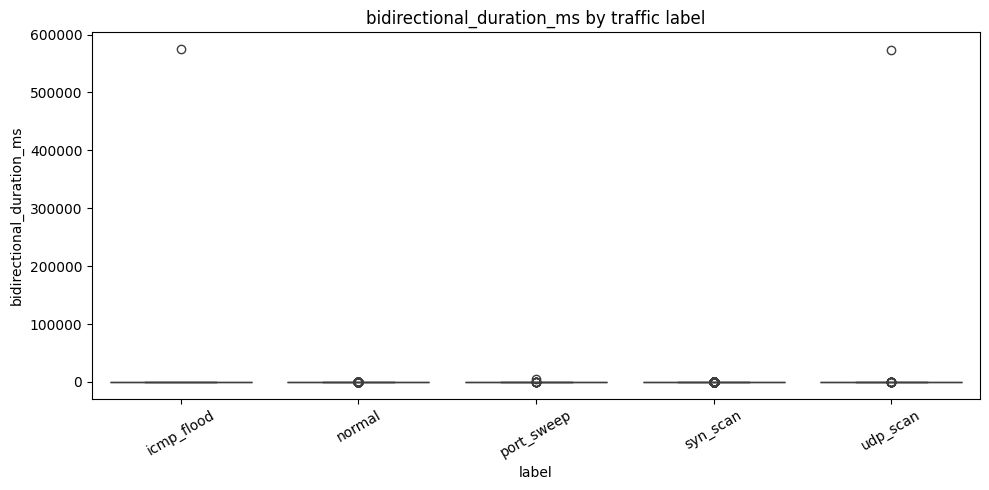

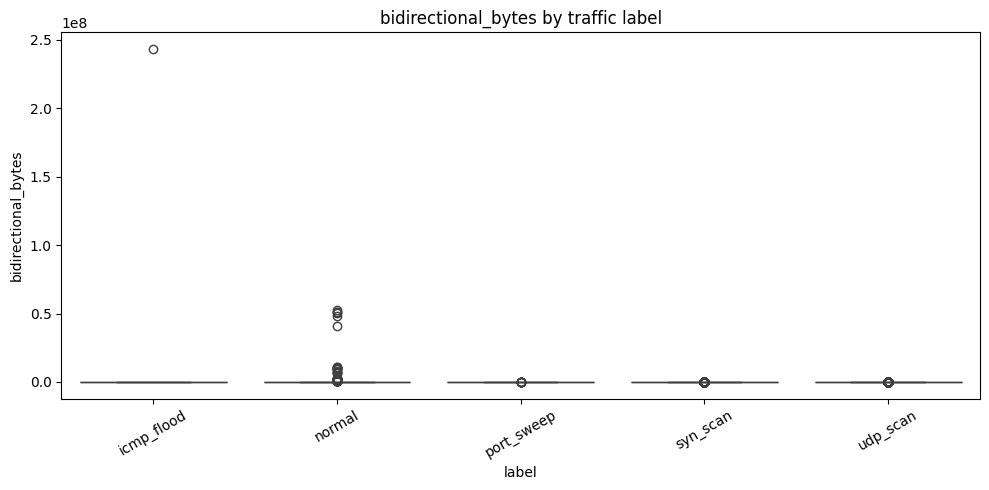

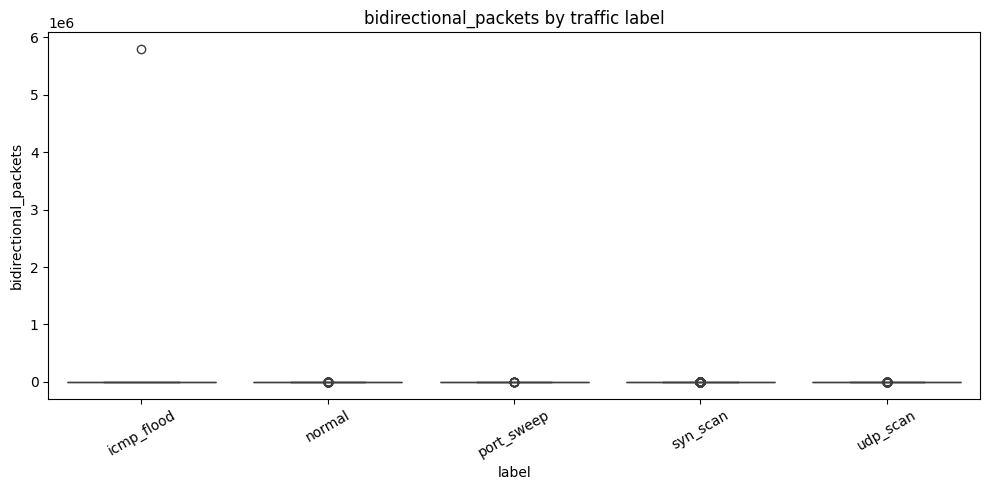

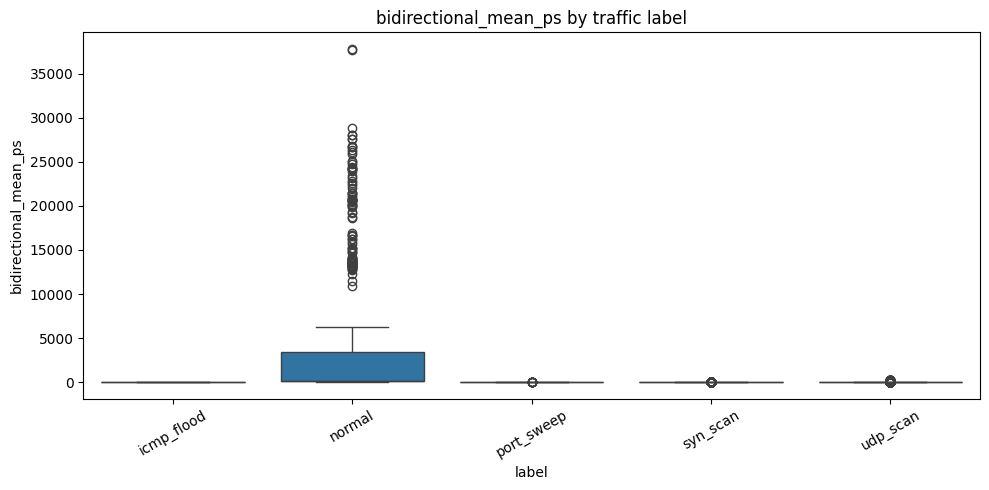

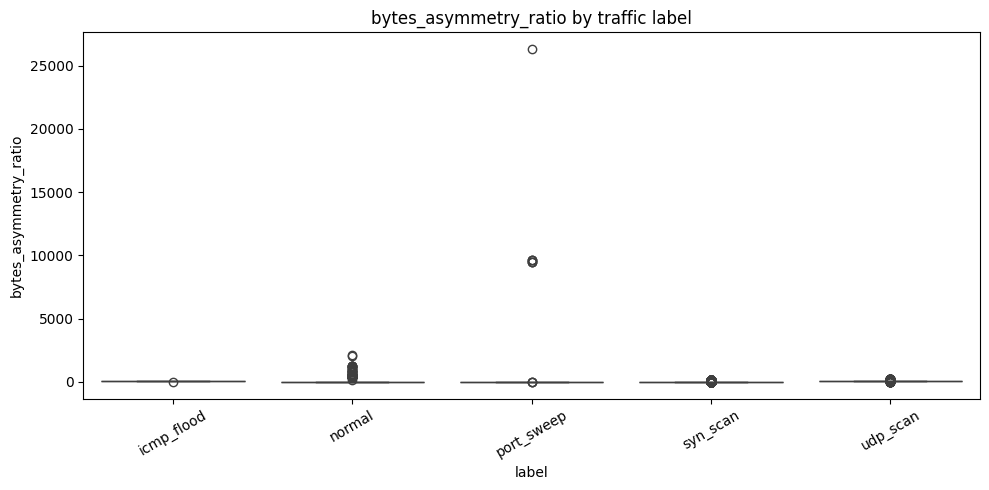

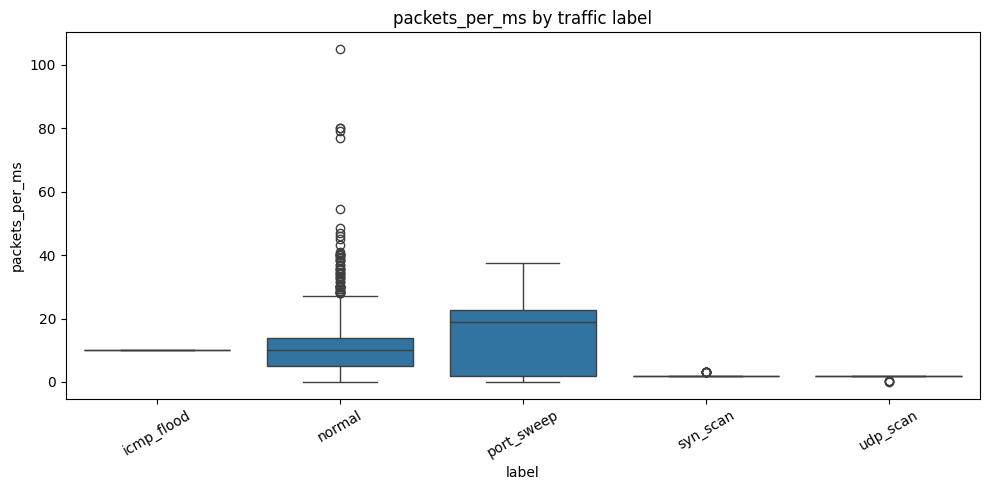

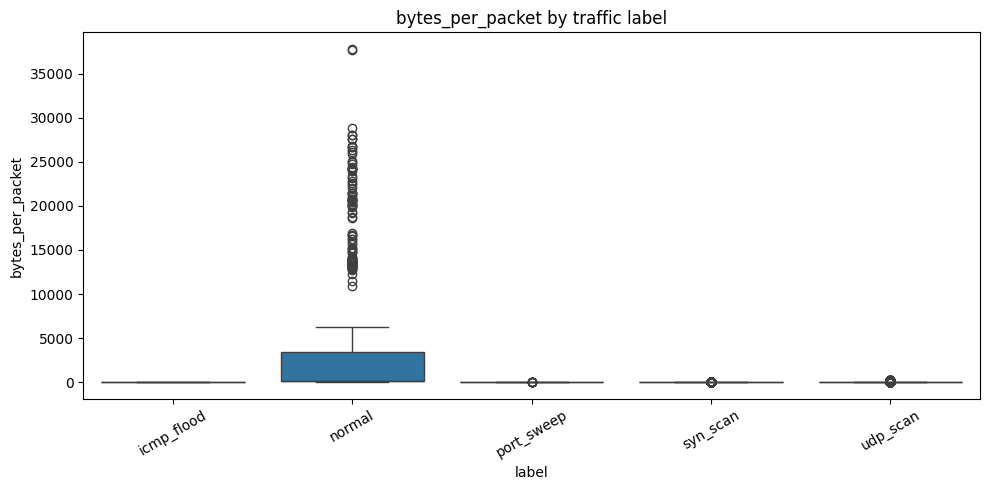

In [27]:
##visualizacions rápidas por categoría
plot_cols = [
    "bidirectional_duration_ms",
    "bidirectional_bytes",
    "bidirectional_packets",
    "bidirectional_mean_ps",
    "bytes_asymmetry_ratio",
    "packets_per_ms",
    "bytes_per_packet",
]

for col in plot_cols:
    if col not in all_flows.columns:
        print(f"Skipping missing column: {col}")
        continue

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=all_flows, x="label", y=col)
    plt.title(f"{col} by traffic label")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## Initial visual comparison

The boxplots above provide a first visual comparison between traffic categories. The goal is to check whether basic L3/L4 flow features show different distributions across labels.

Expected patterns:
- Scan traffic should usually have shorter durations and lower byte counts.
- Flood traffic should show high packet rates or many similar packets.
- Normal traffic should show more variability in duration, bytes and packet size.

In [28]:
##vista compacta de columnas importantes
important_cols_available = [
    col for col in [
        "label",
        "pcap_file",
        "src_ip",
        "dst_ip",
        "src_port",
        "dst_port",
        "protocol",
        "protocol_name",
        "bidirectional_duration_ms",
        "bidirectional_packets",
        "bidirectional_bytes",
        "src2dst_packets",
        "src2dst_bytes",
        "dst2src_packets",
        "dst2src_bytes",
        "bidirectional_mean_ps",
        "bytes_asymmetry_ratio",
        "packets_asymmetry_ratio",
        "packets_per_ms",
        "bytes_per_packet",
    ]
    if col in all_flows.columns
]

important_preview = all_flows[important_cols_available].copy()

important_preview.head(20)

,label,pcap_file,src_ip,dst_ip,src_port,dst_port,protocol,protocol_name,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_packets,src2dst_bytes,dst2src_packets,dst2src_bytes,bidirectional_mean_ps,bytes_asymmetry_ratio,packets_asymmetry_ratio,packets_per_ms,bytes_per_packet
0,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.1,127.0.0.11,34586,46281,17,UDP,0,1,66,1,66,0,0,66.0,67.0,2.0,NaN,66.0
1,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.11,127.0.0.1,53,34586,17,UDP,0,1,88,1,88,0,0,88.0,89.0,2.0,NaN,88.0
2,icmp_flood,icmp_flood_week1_final.pcap,172.20.0.30,172.20.0.10,0,0,1,ICMP,575162,5793854,243341868,2896927,121670934,2896927,121670934,42.0,1.0,1.0,10.07343,42.0
3,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.1,127.0.0.11,56112,46281,17,UDP,0,1,66,1,66,0,0,66.0,67.0,2.0,NaN,66.0
4,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.11,127.0.0.1,53,56112,17,UDP,0,1,88,1,88,0,0,88.0,89.0,2.0,NaN,88.0
5,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.1,127.0.0.11,53561,46281,17,UDP,0,1,66,1,66,0,0,66.0,67.0,2.0,NaN,66.0
6,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.11,127.0.0.1,53,53561,17,UDP,0,1,88,1,88,0,0,88.0,89.0,2.0,NaN,88.0
7,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.1,127.0.0.11,55038,46281,17,UDP,0,1,66,1,66,0,0,66.0,67.0,2.0,NaN,66.0
8,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.11,127.0.0.1,53,55038,17,UDP,0,1,88,1,88,0,0,88.0,89.0,2.0,NaN,88.0
9,icmp_flood,icmp_flood_week1_final.pcap,127.0.0.1,127.0.0.11,40437,46281,17,UDP,0,1,66,1,66,0,0,66.0,67.0,2.0,NaN,66.0


In [29]:
important_preview_path = PROCESSED_DIR / "nfstream_important_columns_preview.csv"
important_preview.to_csv(important_preview_path, index=False)

print("Saved:", important_preview_path)

Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_important_columns_preview.csv


In [30]:
##guardar dataframe completo exploratorio
all_flows_path = PROCESSED_DIR / "nfstream_all_flows_exploration.csv"
all_flows.to_csv(all_flows_path, index=False)

print("Saved:", all_flows_path)
print("Rows:", all_flows.shape[0])
print("Columns:", all_flows.shape[1])

Saved: /home/angel/projects/CNC_Project/data/processed/nfstream_all_flows_exploration.csv
Rows: 80571
Columns: 98


In [31]:
##markdown de cierre del día
labels_found = all_flows["label"].value_counts().to_frame("n_flows")

tcp_flag_text = (
    ", ".join(flag_columns)
    if flag_columns
    else "No explicit TCP flag columns were detected in this NFStream output. TCP flags will be computed manually with Scapy."
)

l7_text = (
    ", ".join(potential_l7_columns[:30])
    if potential_l7_columns
    else "No obvious L7 columns detected."
)

notes = f"""# Week 2 Day 1 - NFStream Exploration Notes

## Objective

Explore NFStream flow extraction from normalized PCAP files and identify relevant L3/L4 columns for the feature engineering stage.

## Technical compatibility issue

The original Docker/WSL PCAPs were captured using Linux cooked capture v2 (`LINUX_SLL2`). NFStream failed to extract flows directly from that format. To solve this, the PCAPs were normalized into Ethernet/IP PCAPs under:

`data/interim/nfstream_compatible`

The normalization preserves timestamps and L3/L4 headers while replacing only the link-layer header. This is acceptable because the project does not use Ethernet MAC addresses or L2 fields as Machine Learning features.

## Processed PCAPs

{processed_pcaps_summary.to_markdown(index=False)}

## Combined DataFrame

- Total flows: {all_flows.shape[0]}
- Total columns: {all_flows.shape[1]}

## Labels found

{labels_found.to_markdown()}

## Summary by label

{summary_by_label.to_markdown(index=False)}

## Key NFStream column families

### Flow identity

- `src_ip`
- `dst_ip`
- `src_port`
- `dst_port`
- `protocol`

### Timing

- `bidirectional_first_seen_ms`
- `bidirectional_last_seen_ms`
- `bidirectional_duration_ms`

### Volume

- `bidirectional_packets`
- `bidirectional_bytes`
- `src2dst_packets`
- `src2dst_bytes`
- `dst2src_packets`
- `dst2src_bytes`

### Packet size

- `bidirectional_mean_ps`
- `bidirectional_min_ps`
- `bidirectional_max_ps`
- `bidirectional_stddev_ps`

### Directional asymmetry

Derived exploratory features:

- `bytes_asymmetry_ratio`
- `packets_asymmetry_ratio`

### Packet rate

Derived exploratory feature:

- `packets_per_ms`

## Bidirectional vs directional flows

NFStream represents each flow as a bidirectional communication. The `bidirectional_*` columns summarize both directions together. The `src2dst_*` columns describe packets from the initial source to the destination. The `dst2src_*` columns describe packets in the reverse direction.

This distinction is important because normal client-server traffic usually contains both requests and responses, while scans and floods often produce asymmetric flows.

## TCP flags

{tcp_flag_text}

## L7 columns excluded from final ML features

Potential L7/application metadata columns detected:

{l7_text}

These columns will not be used in the final ML feature set because the project focuses on L3/L4 features without payload inspection.

## Initial findings

The first NFStream exploration confirms that the dataset can be converted into a flow-level table. Duration, bytes, packets, packet size and directional asymmetry are available or derivable and are suitable candidates for the next feature selection stage.

The next step is to formalize the selected features and compute advanced manual features with Scapy, including IAT, RTT estimate, TCP window statistics and SYN/ACK ratio.
"""

notes_path = DOCS_DIR / "week2_day1_nfstream_notes.md"
notes_path.write_text(notes, encoding="utf-8")

print("Saved:", notes_path)

Saved: /home/angel/projects/CNC_Project/docs/week2_day1_nfstream_notes.md


# Day 1 conclusion

NFStream was successfully used to generate a first flow-level DataFrame from the normalized PCAP dataset. The original captures required normalization because they were stored as Linux cooked capture v2, which was not directly usable by NFStream in this environment.

The exploration identified the most relevant L3/L4 feature families:

- flow duration,
- total packets,
- total bytes,
- directional packet and byte counts,
- packet size statistics,
- directional asymmetry,
- packet rate,
- TCP flag availability.

The distinction between `bidirectional_*`, `src2dst_*` and `dst2src_*` was also documented. This distinction is central for detecting scans and floods, because these traffic types often generate asymmetric flows.

The next step is to formalize the selected features and implement manual Scapy-based features such as IAT, RTT estimate, TCP window statistics and SYN/ACK ratio.